In [ ]:
import os
from warnings import filterwarnings
!pip -q install sentence-transformers transformers accelerate pillow requests scikit-learn
import numpy as np
import pandas as pd
import requests
from io import BytesIO
from PIL import Image
import torch
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import OneHotEncoder

from transformers import CLIPProcessor, CLIPModel

filterwarnings('ignore')

In [ ]:
os.listdir()

['.config', 'Merged_data.csv', 'sample_data']

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(r"Merged_data.csv")

In [ ]:
df.shape

(5223, 7)

In [ ]:
df.head()

,subreddit,permalink,score,num_comments,title,body_text,image_url
0,Medicine,https://old.reddit.com/r/medicine/comments/qzu...,8052,599,A detailed description of how you die from COV...,Good morning.\nI squeeze your hand.\n“It’s Fri...,NaN
1,Medicine,https://old.reddit.com/r/medicine/comments/fp2...,4956,356,3 Days of Inpatient Care in New York,NaN,NaN
2,Medicine,https://old.reddit.com/r/medicine/comments/kb3...,4808,132,Help! A doctor in my hometown was kidnapped by...,NaN,NaN
3,Medicine,https://old.reddit.com/r/medicine/comments/rqx...,4614,405,Powerless [Rant],NaN,NaN
4,Medicine,https://old.reddit.com/r/medicine/comments/fnz...,4421,335,"Dr. Usama Riaz has spent weeks screening, trea...",NaN,NaN


In [ ]:
df['subreddit'].value_counts()

,count
subreddit,
IndiaTech,202
india,198
technology,101
Cooking,101
confession,101
worldnews,101
space,101
explainlikeimfive,101
IndianStartups,101


In [ ]:
print(df.shape)
df = df.drop_duplicates()
print(df.shape)

(5223, 7)
(5205, 7)


In [ ]:
df[['score','num_comments']].describe()

,score,num_comments
count,5205.000000,5205.000000
mean,43692.887224,2200.800768
std,54378.291331,4750.824057
min,0.000000,0.000000
25%,6100.000000,222.000000
50%,17610.000000,762.000000
75%,75475.000000,2341.000000
max,440012.000000,99485.000000


<Axes: >

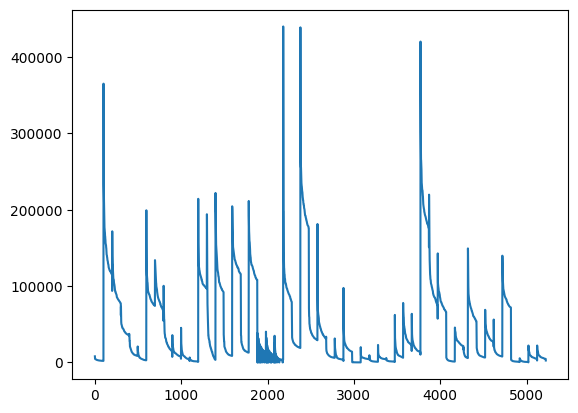

In [ ]:
df['score'].plot()

<Axes: xlabel='score', ylabel='num_comments'>

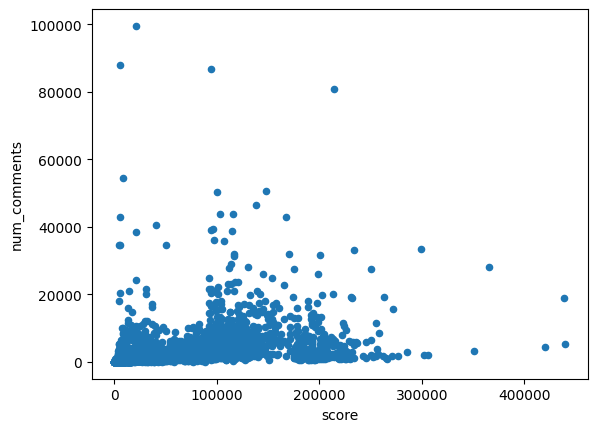

In [ ]:
df.plot(x = 'score',y = 'num_comments',kind = 'scatter')

In [ ]:
def get_features(df):
  df['title_length'] = df['title'].apply(lambda x : len(x))
  df['total_word_counts'] = df['body_text'].fillna('').apply(lambda x : len(x.split()))
  df['body_length'] = df['body_text'].fillna('').apply(lambda x : len(x))
  df['special_chars'] = df['body_text'].astype(str).str.count(r"[A-Za-z0-9\s]")
  from textblob import TextBlob
  df['sentiment_title'] = df['title'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
  df['sentiment_body'] = df['body_text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
  return df

In [ ]:
df_with_image = get_features(df[~df['image_url'].isna()])
df_without_image = get_features(df[df['image_url'].isna()])

In [ ]:
df = df.reset_index(drop = True)

In [ ]:
df = df.copy()
df["title"] = df["title"].fillna("").astype(str)
df["body_text"] = df["body_text"].fillna("").astype(str)
df["subreddit"] = df["subreddit"].fillna("missing").astype(str)
df["image_url"] = df["image_url"].astype(str)
df.loc[df["image_url"].isin(["nan", "None", "NaN", ""]), "image_url"] = ""
df["has_image"] = df["image_url"].str.len().gt(0)
df.head()

,subreddit,permalink,score,num_comments,title,body_text,image_url,has_image
0,Medicine,https://old.reddit.com/r/medicine/comments/qzu...,8052,599,A detailed description of how you die from COV...,Good morning.\nI squeeze your hand.\n“It’s Fri...,,False
1,Medicine,https://old.reddit.com/r/medicine/comments/fp2...,4956,356,3 Days of Inpatient Care in New York,,,False
2,Medicine,https://old.reddit.com/r/medicine/comments/kb3...,4808,132,Help! A doctor in my hometown was kidnapped by...,,,False
3,Medicine,https://old.reddit.com/r/medicine/comments/rqx...,4614,405,Powerless [Rant],,,False
4,Medicine,https://old.reddit.com/r/medicine/comments/fnz...,4421,335,"Dr. Usama Riaz has spent weeks screening, trea...",,,False


In [ ]:
text_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
title_emb = text_model.encode(
    df["title"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)
body_emb = text_model.encode(
    df["body_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)
print("title_emb:", title_emb.shape, "body_emb:", body_emb.shape)

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

Batches:   0%|          | 0/82 [00:00<?, ?it/s]

title_emb: (5205, 384) body_emb: (5205, 384)


In [ ]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
sub_ohe = ohe.fit_transform(df[["subreddit"]])
print("sub_ohe:", sub_ohe.shape)


sub_ohe: (5205, 51)


In [ ]:
from tqdm.auto import tqdm

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

clip_model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

def fetch_image(url: str, timeout: int = 8, retries: int = 2):
    if not url:
        return None
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    for _ in range(retries + 1):
        try:
            r = requests.get(url, timeout=timeout, headers=headers)
            if r.status_code != 200:
                continue
            img = Image.open(BytesIO(r.content)).convert("RGB")
            return img
        except Exception:
            continue
    return None

@torch.no_grad()
def clip_embed_images(pil_images):
    inputs = clip_processor(images=pil_images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    feats = clip_model.get_image_features(**inputs)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu().numpy()
n = len(df)
clip_emb = None
img_indices = df.index[df["has_image"]].tolist()
img_urls = df.loc[img_indices, "image_url"].tolist()
batch_urls = 16
batch_embed = 32
loaded_images = []
loaded_rows = []
def flush_batch():
    global clip_emb, loaded_images, loaded_rows
    if not loaded_images:
        return
    all_vecs = []
    for i in range(0, len(loaded_images), batch_embed):
        chunk = loaded_images[i:i+batch_embed]
        vecs = clip_embed_images(chunk)
        all_vecs.append(vecs)
    vecs = np.vstack(all_vecs)
    if clip_emb is None:
        D = vecs.shape[1]
        clip_emb = np.zeros((n, D), dtype=np.float32)
    for row_i, v in zip(loaded_rows, vecs):
        clip_emb[row_i] = v.astype(np.float32)

    loaded_images = []
    loaded_rows = []
for start in tqdm(range(0, len(img_urls), batch_urls)):
    urls_chunk = img_urls[start:start+batch_urls]
    rows_chunk = img_indices[start:start+batch_urls]

    for row_id, url in tqdm(zip(rows_chunk, urls_chunk),leave = False):
        img = fetch_image(url, timeout=8, retries=2)
        if img is not None:
            loaded_images.append(img)
            loaded_rows.append(row_id)
    flush_batch()
if clip_emb is None:
    clip_emb = np.zeros((n, 512), dtype=np.float32)
print("clip_emb:", clip_emb.shape)


Device: cpu


  0%|          | 0/131 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

clip_emb: (5205, 512)


In [ ]:
has_image_feat = df["has_image"].astype(np.float32).to_numpy().reshape(-1, 1)
X = np.concatenate(
    [title_emb, body_emb, sub_ohe.astype(np.float32), clip_emb, has_image_feat],
    axis=1
).astype(np.float32)
print("Final X:", X.shape)


Final X: (5205, 1332)


In [ ]:
!pip -q install xgboost lightgbm scikit-learn matplotlib


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.compose import TransformedTargetRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [ ]:
def build_fast_stack(random_state=42):
    base_models = [
        ('hgb', HistGradientBoostingRegressor(
            max_iter=1000, learning_rate=0.1, l2_regularization=1.5, random_state=random_state
        )),
        ('xgb', XGBRegressor(
            tree_method='hist',
            n_estimators=800,
            learning_rate=0.1,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            max_depth=8,
            random_state=random_state,
            n_jobs=-1
        ))
    ]
    return StackingRegressor(
        estimators=base_models,
        final_estimator=RidgeCV(),
        cv=3,
        n_jobs=-1
    )

def build_ultimate_model(random_state=42):
    lgb_model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        importance_type='gain',
        reg_alpha=0.1,
        reg_lambda=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1
    )

    hgb_model = HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.03,
        max_depth=12,
        l2_regularization=2.0,
        random_state=random_state
    )

    ensemble = VotingRegressor(estimators=[
        ('lgb', lgb_model),
        ('hgb', hgb_model)
    ])

    return TransformedTargetRegressor(
        regressor=ensemble,
        func=np.log1p,
        inverse_func=np.expm1
    )


In [ ]:
def evaluate_and_plot(y_true, y_pred, title=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    print(f"{title}")
    print(f"  R2  : {r2:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  MSE : {mse:.4f}")

    # Scatter: predicted vs actual
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.25)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx])
    plt.title(f"{title} | Predicted vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

    # Residual plot
    plt.figure()
    residuals = y_pred - y_true
    plt.scatter(y_pred, residuals, alpha=0.25)
    plt.axhline(0)
    plt.title(f"{title} | Residuals vs Predicted")
    plt.xlabel("Predicted")
    plt.ylabel("Residual (pred-true)")
    plt.show()

    return {"r2": r2, "mae": mae, "mse": mse}


In [ ]:
def train_test_one_target(X, y, model, target_name="target",
                          test_size=0.2, random_state=42, use_log1p=False):
    # train-test split for THIS target
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    if use_log1p:
        y_tr_fit = np.log1p(y_tr)
        model.fit(X_tr, y_tr_fit)
        y_pred = np.expm1(model.predict(X_te))
        title = f"{target_name} | {model.__class__.__name__} | manual log1p"
    else:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        title = f"{target_name} | {model.__class__.__name__} | raw target"

    return evaluate_and_plot(y_te, y_pred, title=title)


===== TARGET: score =====
score | StackingRegressor | raw target
  R2  : 0.9112
  MAE : 8012.5028
  MSE : 257319159.9341


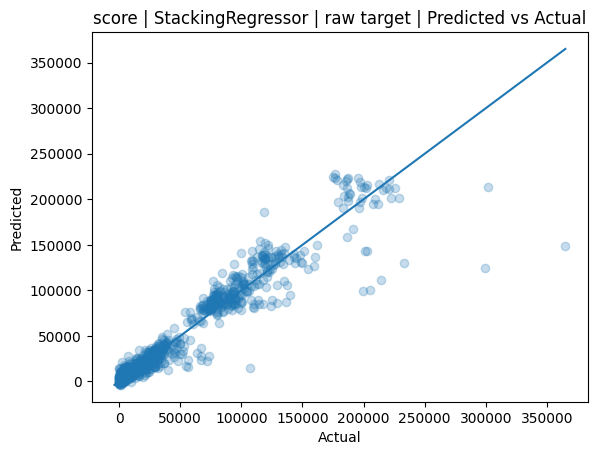

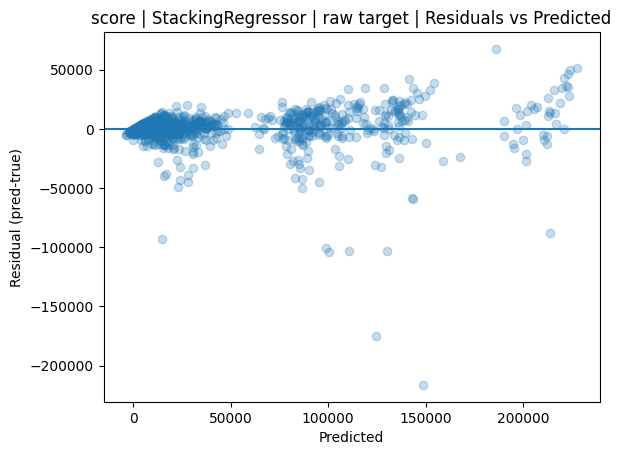

score | StackingRegressor | manual log1p
  R2  : 0.8702
  MAE : 9378.8755
  MSE : 376082408.1261


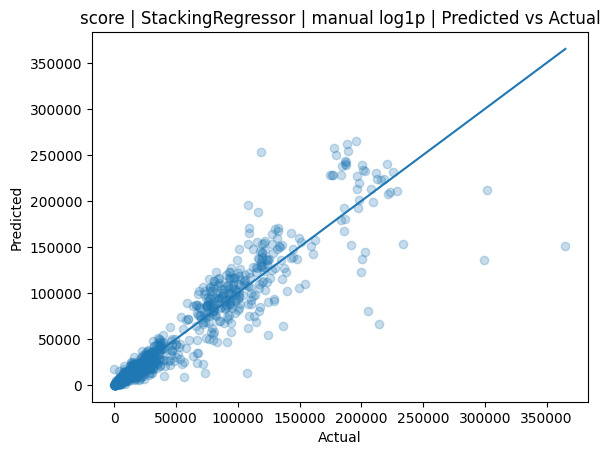

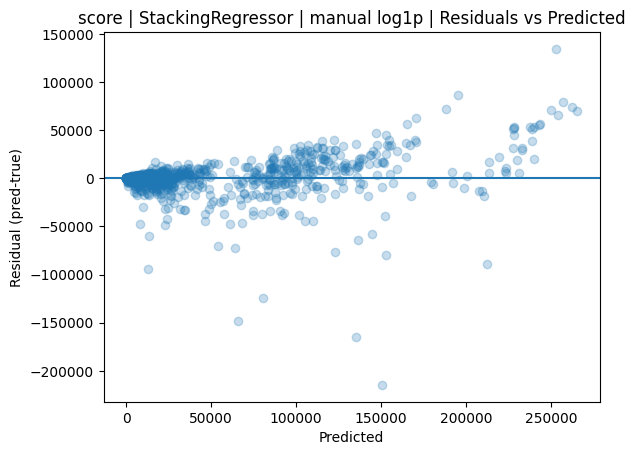

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.191062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 326121
[LightGBM] [Info] Number of data points in the train set: 4164, number of used features: 1332
[LightGBM] [Info] Start training from score 9.724388
score | TransformedTargetRegressor | raw target
  R2  : 0.8667
  MAE : 9293.7922
  MSE : 386184599.9842


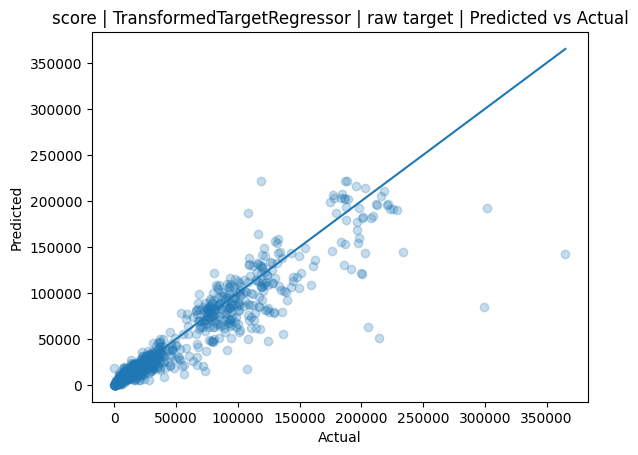

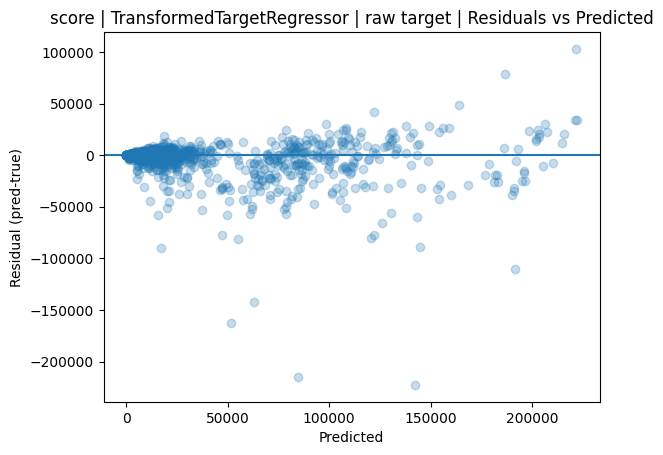


===== TARGET: num_comments =====
num_comments | StackingRegressor | raw target
  R2  : 0.3592
  MAE : 1438.5453
  MSE : 21071093.5494


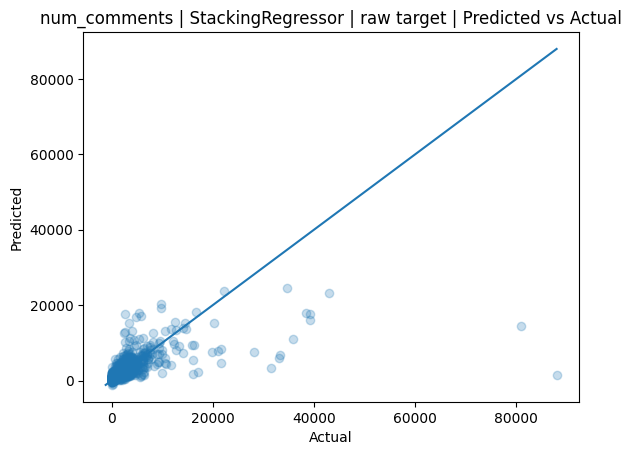

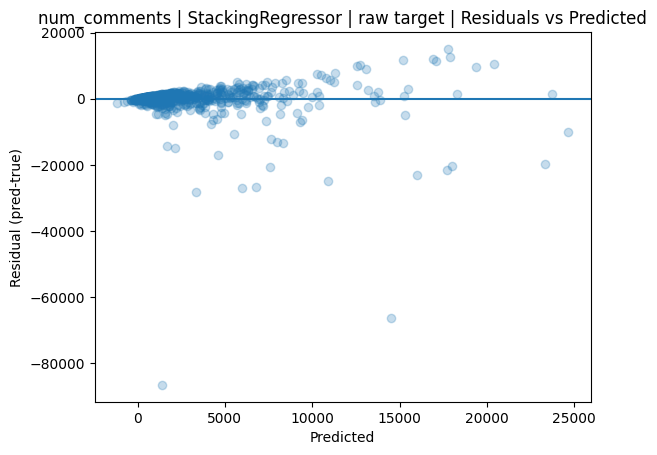

num_comments | StackingRegressor | manual log1p
  R2  : 0.2989
  MAE : 1316.1235
  MSE : 23053826.0644


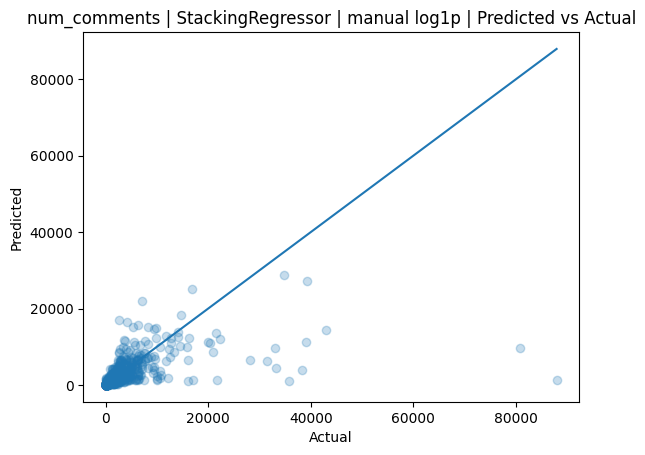

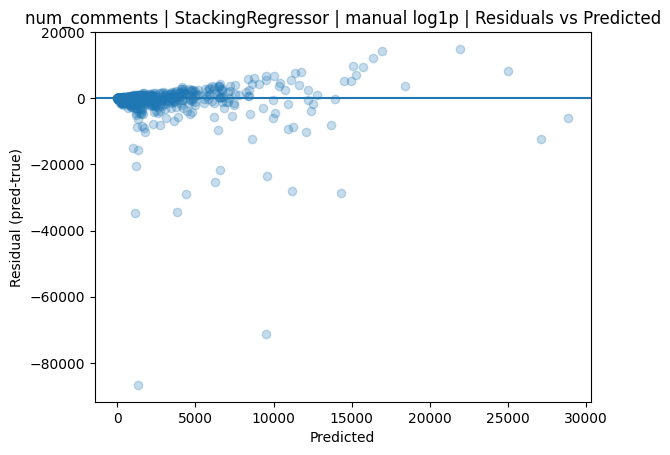

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.137107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 326121
[LightGBM] [Info] Number of data points in the train set: 4164, number of used features: 1332
[LightGBM] [Info] Start training from score 6.527249
num_comments | TransformedTargetRegressor | raw target
  R2  : 0.2449
  MAE : 1310.8051
  MSE : 24829877.9346


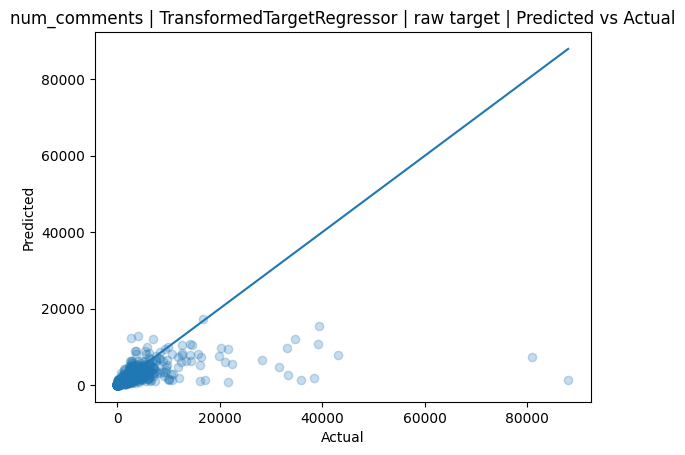

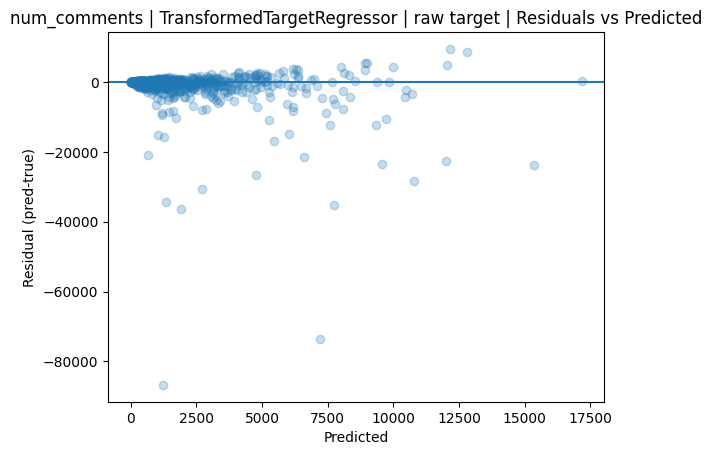

{('score', 'fast_stack_raw'): {'r2': 0.9112005581757174,
  'mae': 8012.502756134266,
  'mse': 257319159.9340943},
 ('score', 'fast_stack_log1p'): {'r2': 0.8702160075056985,
  'mae': 9378.875493651143,
  'mse': 376082408.1260631},
 ('score', 'ultimate_ttr'): {'r2': 0.866729796069157,
  'mae': 9293.792238586055,
  'mse': 386184599.98419017},
 ('num_comments', 'fast_stack_raw'): {'r2': 0.35923938779429665,
  'mae': 1438.5453297345036,
  'mse': 21071093.549396444},
 ('num_comments', 'fast_stack_log1p'): {'r2': 0.29894555932291256,
  'mae': 1316.1234698951585,
  'mse': 23053826.06442804},
 ('num_comments', 'ultimate_ttr'): {'r2': 0.24493677800408575,
  'mae': 1310.8051383263512,
  'mse': 24829877.934627194}}

In [ ]:
# Targets
y_score = df["score"].astype(float).to_numpy()
y_comments = df["num_comments"].astype(float).to_numpy()

results = {}

# --- SCORE ---
print("===== TARGET: score =====")
m1 = build_fast_stack()
results[("score", "fast_stack_raw")] = train_test_one_target(X, y_score, m1, "score", use_log1p=False)

m2 = build_fast_stack()
results[("score", "fast_stack_log1p")] = train_test_one_target(X, y_score, m2, "score", use_log1p=True)

m3 = build_ultimate_model()
results[("score", "ultimate_ttr")] = train_test_one_target(X, y_score, m3, "score", use_log1p=False)

# --- NUM ---
print("\n===== TARGET: num_comments =====")
m4 = build_fast_stack()
results[("num_comments", "fast_stack_raw")] = train_test_one_target(X, y_comments, m4, "num_comments", use_log1p=False)

m5 = build_fast_stack()
results[("num_comments", "fast_stack_log1p")] = train_test_one_target(X, y_comments, m5, "num_comments", use_log1p=True)

m6 = build_ultimate_model()
results[("num_comments", "ultimate_ttr")] = train_test_one_target(X, y_comments, m6, "num_comments", use_log1p=False)

results
